# Imports libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.impute import KNNImputer
sns.set_style("whitegrid")


# Data Loading and Exploration

In [2]:
df = pd.read_csv("/content/Dataset for Data Analytics - Sheet1.csv")

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nMemory usage:\n{df.info(memory_usage='deep')}")

Shape: (1200, 14)

Columns:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']

Data types:
OrderID             object
Date                object
CustomerID          object
Product             object
Quantity             int64
UnitPrice          float64
ShippingAddress     object
PaymentMethod       object
OrderStatus         object
TrackingNumber      object
ItemsInCart          int64
CouponCode          object
ReferralSource      object
TotalPrice         float64
dtype: object

Duplicate rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Produc

# Handling missing values



The numeric values (Quantity, UnitPrice, ItemsInCart, TotalPrce) didn't contain any missing values.
Only the (CouponCode category had 309 missing values, which wer handeled using a sentinel value of "no coupon ".      


Missing values before treatment:
CouponCode    309
dtype: int64


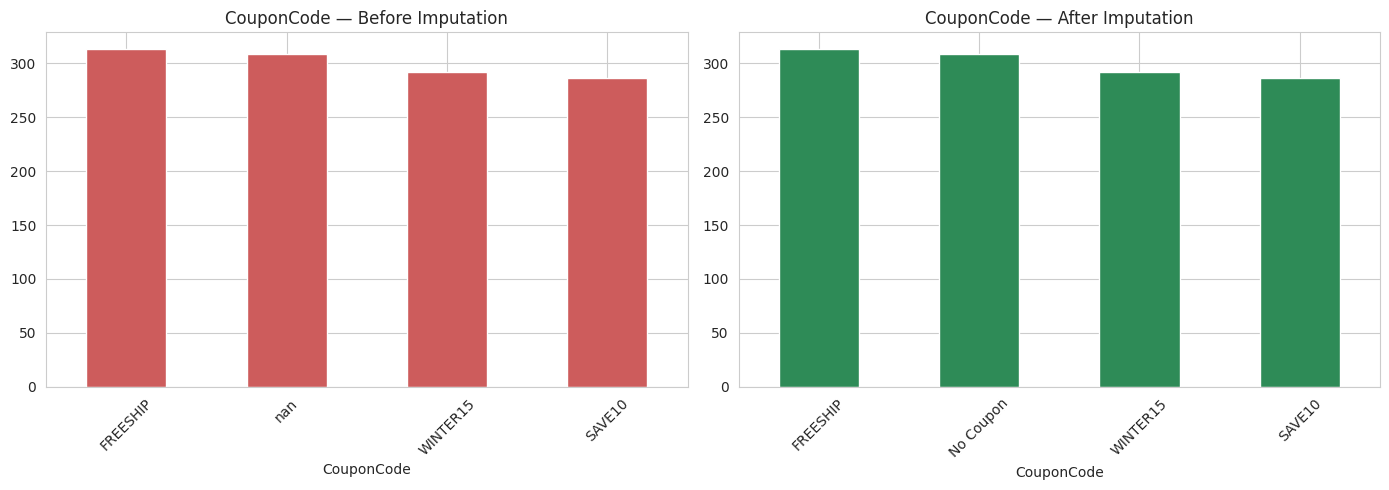


Total missing values remaining: 0


In [3]:
missing_before = df.isnull().sum()

missing_before = missing_before[missing_before > 0]
print(f"\nMissing values before treatment:\n{missing_before}")
before_counts = df['CouponCode'].value_counts(dropna=False)
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')
after_counts = df['CouponCode'].value_counts(dropna=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

before_counts.plot(kind='bar', ax=axes[0], color='indianred')
axes[0].set_title("CouponCode — Before Imputation")
axes[0].tick_params(axis='x', rotation=45)

after_counts.plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title("CouponCode — After Imputation")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\nTotal missing values remaining: {df.isnull().sum().sum()}")

# Outliers Handling

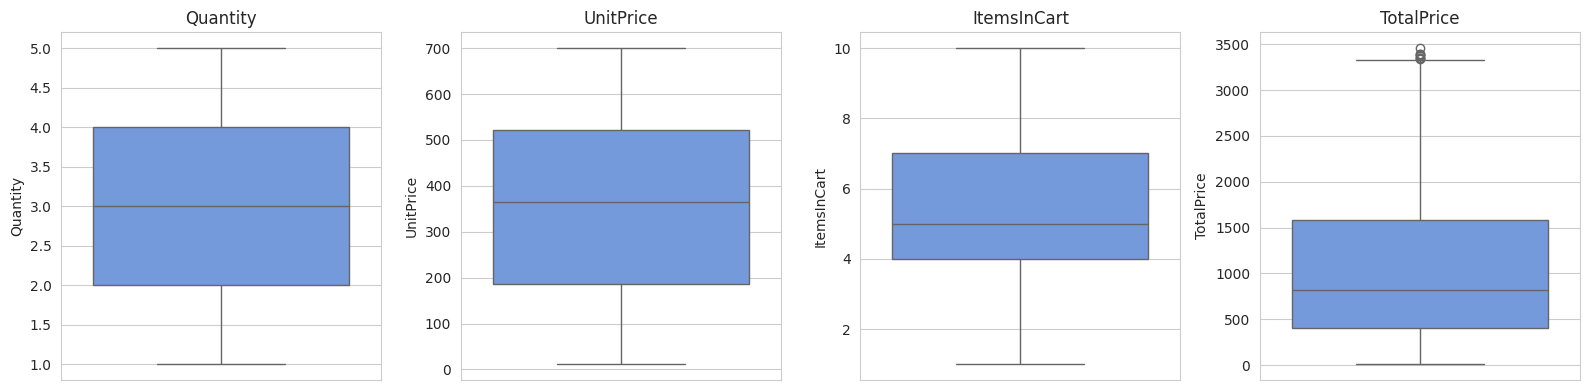

=== Outlier Detection Summary (Z-score vs IQR) ===
        Column  Outliers_ZScore  Outliers_IQR  IQR_Lower  IQR_Upper
0     Quantity                0             0      -1.00       7.00
1    UnitPrice                0             0    -317.20    1024.83
2  ItemsInCart                0             0      -0.50      11.50
3   TotalPrice                0             8   -1341.41    3330.41


In [4]:
# ============================================================
#   OUTLIER DETECTION & TREATMENT
# ============================================================

numerical_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

fig, axes = plt.subplots(1, len(numerical_cols), figsize=(16, 4))

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='cornflowerblue')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
#  Detection functions
# ------------------------------------------------------------
def detect_outliers_zscore(df, col, threshold=3):

    z_scores = np.abs(stats.zscore(df[col]))
    mask = z_scores > threshold
    return df[mask], z_scores


def detect_outliers_iqr(df, col):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (df[col] < lower) | (df[col] > upper)
    return df[mask], lower, upper


summary_rows = []

for col in numerical_cols:
    outliers_z, _ = detect_outliers_zscore(df, col, threshold=3)
    outliers_iqr, lower, upper = detect_outliers_iqr(df, col)

    summary_rows.append({
        'Column': col,
        'Outliers_ZScore': len(outliers_z),
        'Outliers_IQR': len(outliers_iqr),
        'IQR_Lower': round(lower, 2),
        'IQR_Upper': round(upper, 2)
    })

outlier_summary = pd.DataFrame(summary_rows)
print("=== Outlier Detection Summary (Z-score vs IQR) ===")
print(outlier_summary)



1.   Quantity, UnitPrice, itemsincart: Box plots do not show any whiskers extending beyond the edges of the box into the marked area; no outliers are observed for either method, which is consistent with their limited/discrete ranges.
2.   Total Price : The box plot clearly shows a few data points above the upper whisker (visible as small diamonds or dots at the top, between approximately 3,300 and 3,450), which correspond to the 8 outliers detected within the IQR.   



In [5]:
# ------------------------------------------------------------
# Detailed inspection: where the two methods actually disagree
# ------------------------------------------------------------
outliers_iqr_total, lower, upper = detect_outliers_iqr(df, 'TotalPrice')

print(f"\nTotalPrice outliers (IQR method) — bounds [{lower:.2f} ; {upper:.2f}]:")
print(outliers_iqr_total[['OrderID', 'Quantity', 'UnitPrice', 'TotalPrice',
                           'OrderStatus', 'Product']].sort_values('TotalPrice', ascending=False))


TotalPrice outliers (IQR method) — bounds [-1341.41 ; 3330.41]:
        OrderID  Quantity  UnitPrice  TotalPrice OrderStatus  Product
789   ORD200789         5     691.28     3456.40   Delivered   Tablet
1122  ORD201122         5     678.19     3390.95    Returned  Monitor
632   ORD200632         5     678.16     3390.80   Delivered   Laptop
469   ORD200469         5     676.98     3384.90   Cancelled    Chair
328   ORD200328         5     674.04     3370.20   Cancelled   Tablet
107   ORD200107         5     670.75     3353.75     Shipped  Printer
326   ORD200326         5     670.48     3352.40    Returned   Laptop
1065  ORD201065         5     666.80     3334.00   Delivered  Printer


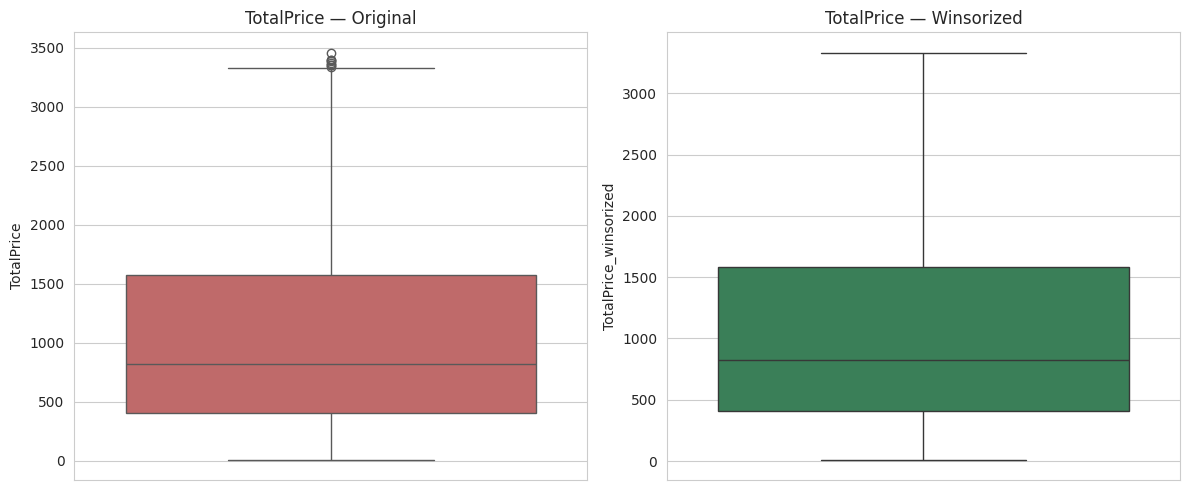

      TotalPrice  TotalPrice_winsorized
min      11.3900              11.390000
max    3456.4000            3330.407500
mean   1053.9683            1053.643183


In [6]:
# ------------------------------------------------------------
#   Treatment — Winsorization
# ------------------------------------------------------------
df['TotalPrice_winsorized'] = np.clip(df['TotalPrice'], lower, upper)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df['TotalPrice'], ax=axes[0], color='indianred')
axes[0].set_title("TotalPrice — Original")
sns.boxplot(y=df['TotalPrice_winsorized'], ax=axes[1], color='seagreen')
axes[1].set_title("TotalPrice — Winsorized")
plt.tight_layout()
plt.show()

print(df[['TotalPrice', 'TotalPrice_winsorized']].describe().loc[['min', 'max', 'mean']])

# Feature Engineering

In [7]:
df['Has_Coupon'] = (df['CouponCode'] != 'No Coupon').astype(int)
df['Discount_Amount'] = (df['Quantity'] * df['UnitPrice']) - df['TotalPrice']

df['Date'] = pd.to_datetime(df['Date'])

df['Order_Month'] = df['Date'].dt.month
df['Order_Weekday_Num'] = df['Date'].dt.dayofweek
df['Is_Weekend'] = df['Order_Weekday_Num'].isin([5, 6]).astype(int)
df['N_Payment_Methods_Used'] = df['CustomerID'].map(df.groupby('CustomerID')['PaymentMethod'].nunique())

df['N_Coupons_Used'] = df['CustomerID'].map(df.groupby('CustomerID')['CouponCode'].nunique())



df['N_Shipping_Addresses'] = df['CustomerID'].map(df.groupby('CustomerID')['ShippingAddress'].nunique())

df['Discount_Amount'] = (df['Quantity'] * df['UnitPrice']) - df['TotalPrice']
df['Discount_Ratio'] = df['Discount_Amount'] / (df['Quantity'] * df['UnitPrice'])




# Exploratory Data Analysis

OrderID                   1200
TrackingNumber            1200
TotalPrice                1195
UnitPrice                 1193
CustomerID                1189
TotalPrice_winsorized     1188
Date                       671
ShippingAddress            655
Discount_Ratio             130
Discount_Amount             12
Order_Month                 12
ItemsInCart                 10
Product                      7
Order_Weekday_Num            7
PaymentMethod                5
Quantity                     5
OrderStatus                  5
ReferralSource               5
CouponCode                   4
Has_Coupon                   2
Is_Weekend                   2
N_Payment_Methods_Used       2
N_Coupons_Used               2
N_Shipping_Addresses         2
dtype: int64


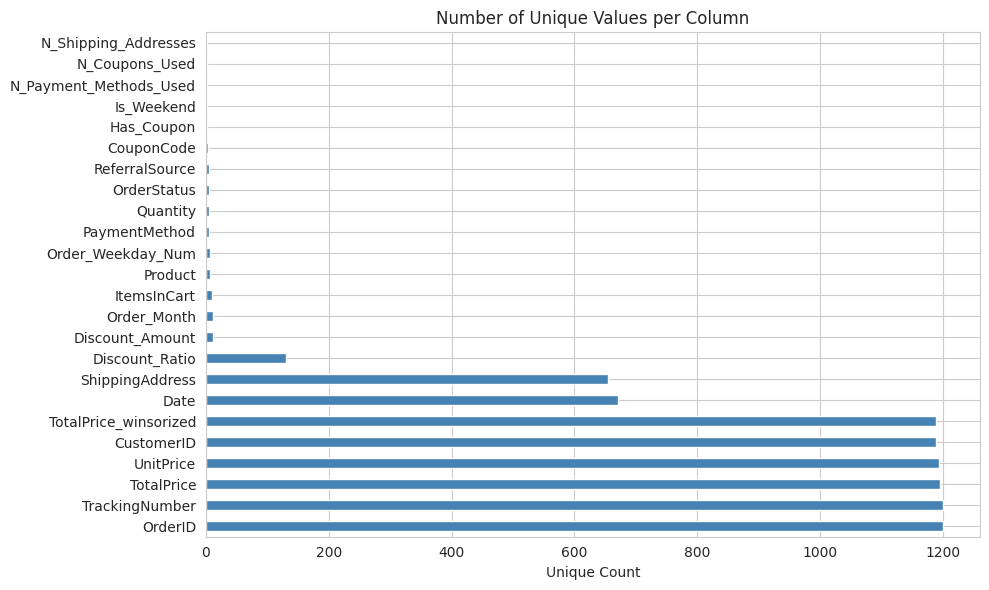

In [8]:
# unique values per column
unique_counts = df.nunique().sort_values(ascending=False)
print(unique_counts)
fig, ax = plt.subplots(figsize=(10, 6))
unique_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("Number of Unique Values per Column")
ax.set_xlabel("Unique Count")
plt.tight_layout()
plt.show()


Date range: 2023-01-01 00:00:00 → 2025-06-30 00:00:00
Span: 911 days


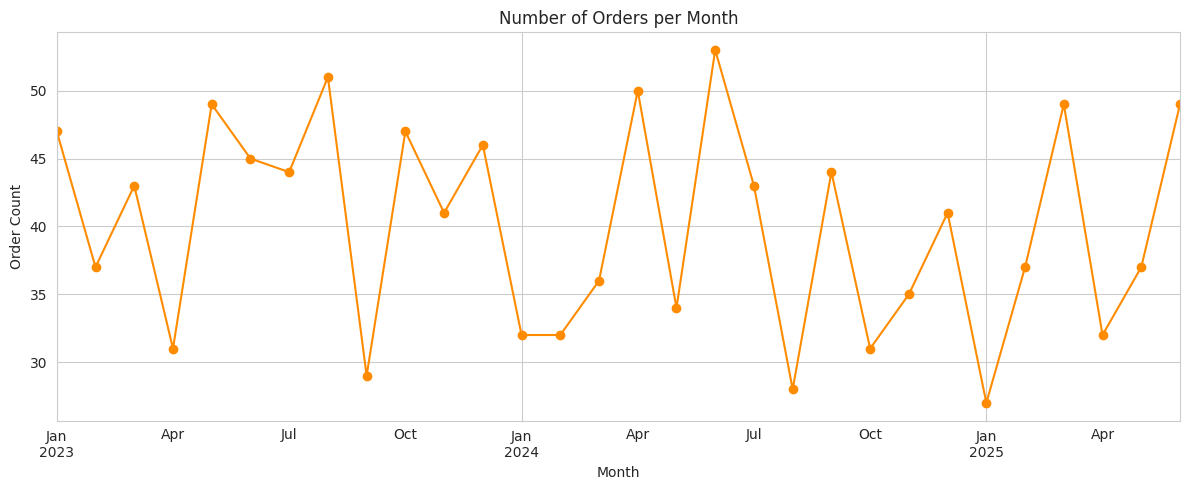

In [9]:
# Date Range
df['Date'] = pd.to_datetime(df['Date'])

print(f"\nDate range: {df['Date'].min()} → {df['Date'].max()}")
print(f"Span: {(df['Date'].max() - df['Date'].min()).days} days")

# Orders volume over time (monthly)
orders_by_month = df.groupby(df['Date'].dt.to_period('M')).size()

fig, ax = plt.subplots(figsize=(12, 5))
orders_by_month.plot(kind='line', marker='o', ax=ax, color='darkorange')
ax.set_title("Number of Orders per Month")
ax.set_xlabel("Month")
ax.set_ylabel("Order Count")
plt.tight_layout()
plt.show()

i  aim  to  check  how the unit price vary, does it vary by product only or coupon code, customr id  .Then undrstand how the coupons are distributed to clients .


In [10]:
# 1. UNITPRICE — WHAT DRIVES ITS VARIATION?

# 1.1 Does UnitPrice vary by Product itself?
print(df.groupby('Product')['UnitPrice'].agg(['mean', 'min', 'max', 'std']))

# 1.2 Does UnitPrice vary by Date?
df['Date'] = pd.to_datetime(df['Date'])
price_by_date = df.groupby(df['Date'].dt.to_period('M'))['UnitPrice'].mean()
print(price_by_date)

# 1.3 Does UnitPrice vary by CustomerID (loyalty)?
customer_order_count = df.groupby('CustomerID')['OrderID'].count()
df['Is_Repeat_Customer'] = df['CustomerID'].map(customer_order_count) > 1
print(df.groupby('Is_Repeat_Customer')['UnitPrice'].mean())

# 1.4 Does UnitPrice vary by Quantity?
print(df.groupby('Quantity')['UnitPrice'].mean())

print(f"Quantity-UnitPrice correlation: {df['Quantity'].corr(df['UnitPrice']):.3f}")

# 1.5 Does UnitPrice vary by CouponCode?
print(df.groupby('CouponCode')['UnitPrice'].mean().sort_values(ascending=False))

# 1.6 Does UnitPrice vary by PaymentMethod?
print(df.groupby('PaymentMethod')['UnitPrice'].mean())

# 1.7 Global ANOVA test: which categorical variable best explains UnitPrice?
from scipy.stats import f_oneway

for col in ['Product', 'CouponCode', 'PaymentMethod', 'OrderStatus', 'ReferralSource']:
    groups = [g['UnitPrice'].values for _, g in df.groupby(col)]
    f_stat, p_val = f_oneway(*groups)
    print(f"{col:20s} → F={f_stat:8.2f}, p-value={p_val:.4f}",
          "→ SIGNIFICANT" if p_val < 0.05 else "→ not significant")


# 2. HOW IS COUPONCODE ASSIGNED TO CUSTOMERS?

# 2.1 Does a customer always use the same coupon, or does it vary?
coupon_per_client = df.groupby('CustomerID')['CouponCode'].nunique().sort_values(ascending=False)
print(coupon_per_client.head(10))


# 2.2 Coupon distribution: balanced, or does one coupon dominate?
print(df['CouponCode'].value_counts())

# 2.3 Is a coupon linked to a specific product or channel?
print(pd.crosstab(df['CouponCode'], df['Product']))
print(pd.crosstab(df['CouponCode'], df['ReferralSource']))


# 3. ITEMSINCART — RELATIONSHIP WITH QUANTITY

# 3.1 Is ItemsInCart == Quantity often, or usually different?
df['Cart_vs_Quantity_Diff'] = df['ItemsInCart'] - df['Quantity']
print(df['Cart_vs_Quantity_Diff'].value_counts().sort_index())

# 3.2 Average ratio (how much of the cart is actually purchased)
df['Conversion_Rate'] = df['Quantity'] / df['ItemsInCart']
print(df['Conversion_Rate'].describe())


# 4. TIME BETWEEN ORDERS (DAY-LEVEL RESOLUTION)

# Number of orders per day
orders_per_day_per_client = df.groupby(['CustomerID', 'Date']).size()
same_day_multiple_orders = orders_per_day_per_client[orders_per_day_per_client > 1]
print(f"Customers with multiple orders on the same day: {len(same_day_multiple_orders)}")


df_sorted = df.sort_values(['CustomerID', 'Date'])
df_sorted['Days_Since_Last_Order'] = df_sorted.groupby('CustomerID')['Date'].diff().dt.days
print(df_sorted[['CustomerID', 'Date', 'Days_Since_Last_Order']].head(15))


# 5. FULL CUSTOMER PROFILE

client_profile = df.groupby('CustomerID').agg(
    Total_Orders=('OrderID', 'count'),
    Total_Quantity=('Quantity', 'sum'),
    Total_Spent=('TotalPrice', 'sum'),
    Avg_UnitPrice=('UnitPrice', 'mean'),
    Products_Bought=('Product', lambda x: list(x.unique())),
    N_Distinct_Products=('Product', 'nunique'),
    Coupons_Used=('CouponCode', lambda x: list(x.unique())),
    Payment_Methods=('PaymentMethod', lambda x: list(x.unique())),
    Order_Dates=('Date', lambda x: list(x.dt.strftime('%Y-%m-%d')))
).sort_values('Total_Spent', ascending=False)

print(client_profile.head(10))

               mean    min     max         std
Product                                       
Chair    355.660281  14.93  695.29  201.302194
Desk     329.608118  26.95  697.93  186.948412
Laptop   357.707052  18.20  699.93  199.350676
Monitor  358.663620  14.69  696.71  203.721772
Phone    375.217564  11.39  695.10  189.098628
Printer  351.714917  12.10  697.19  199.454300
Tablet   367.679106  17.24  699.88  199.287576
Date
2023-01    381.950638
2023-02    381.875405
2023-03    380.944419
2023-04    332.906774
2023-05    426.929796
2023-06    339.548889
2023-07    342.223409
2023-08    325.660784
2023-09    364.088966
2023-10    329.325745
2023-11    365.369024
2023-12    331.753478
2024-01    356.860625
2024-02    357.434687
2024-03    336.844444
2024-04    330.397200
2024-05    312.338824
2024-06    385.283774
2024-07    352.819070
2024-08    364.067143
2024-09    334.068636
2024-10    379.037742
2024-11    368.064000
2024-12    352.209268
2025-01    373.948889
2025-02    368.474054


In [11]:
# CLEANUP: REMOVE REDUNDANT / LOW-VALUE COLUMNS

#  Confirm Conversion_Rate == Cart_Conversion_Rate before dropping
if 'Conversion_Rate' in df.columns and 'Cart_Conversion_Rate' in df.columns:
    print(f"Identical? {(df['Conversion_Rate'] == df['Cart_Conversion_Rate']).all()}")
    df.drop(columns=['Conversion_Rate'], inplace=True)

#  Cart_vs_Quantity_Diff duplicates the same information as Cart_Conversion_Rate
df.drop(columns=['Cart_vs_Quantity_Diff'], inplace=True)

#  Check if Discount_Amount has any real variance before deciding
print(f"\nDiscount_Amount unique values: {df['Discount_Amount'].nunique()}")
print(df['Discount_Amount'].describe())
# If nunique() == 1 (or values are ~0 everywhere due to floating point noise like -4.5e-13):
if df['Discount_Amount'].abs().max() < 0.01:
    print("Discount_Amount is effectively constant (~0) — dropping, no predictive value.")
    df.drop(columns=['Discount_Amount'], inplace=True)

print(f"\nFinal columns:\n{list(df.columns)}")


Discount_Amount unique values: 12
count    1.200000e+03
mean    -2.676378e-15
std      8.098100e-14
min     -4.547474e-13
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.547474e-13
Name: Discount_Amount, dtype: float64
Discount_Amount is effectively constant (~0) — dropping, no predictive value.

Final columns:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice', 'TotalPrice_winsorized', 'Has_Coupon', 'Order_Month', 'Order_Weekday_Num', 'Is_Weekend', 'N_Payment_Methods_Used', 'N_Coupons_Used', 'N_Shipping_Addresses', 'Discount_Ratio', 'Is_Repeat_Customer', 'Conversion_Rate']


In [12]:
df.to_csv('project1_datast.csv', index=False)
